# Feature Mode Decomposition (FMD)

**FMD** (Miao et al., 2022) is a fault-oriented adaptive FIR filter-bank
decomposition. Unlike EMD/VMD, which do not explicitly encode machinery
fault morphology, FMD maximises **correlated kurtosis (CK)** so that each
kept mode is both *impulsive* and *periodic*.

$$
x(t)=\underbrace{\sum_i A_i s(t-iT_a-\upsilon_i)}_{\text{periodic fault impulses}}
+\underbrace{\sum_j B_j s(t-jT_d)}_{\text{random knocks}}
+\underbrace{\sum_k C_k\sin(2\pi f_k t+\phi_k)}_{\text{harmonics}}
+n(t)
$$

with the underdamped resonance kernel (paper Eq. 2)

$$
s(t)=e^{-\eta t}\cos(2\pi f_n t+\theta).
$$

**Reference**

> Y. Miao, B. Zhang, C. Li, J. Lin, D. Zhang.  
> *Feature Mode Decomposition: New Decomposition Theory for Rotating Machinery Fault Diagnosis.*  
> IEEE Transactions on Industrial Electronics, 70(2):1949–1962, 2023.  
> DOI: [10.1109/TIE.2022.3156156](https://doi.org/10.1109/TIE.2022.3156156)

MATLAB demo (File Exchange): `FMD.m` + `x.mat`. This notebook uses
`pysdkit.FMD` and the packaged copy of that demo signal via
`pysdkit.data.test_fmd`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

from pysdkit import FMD
from pysdkit.data import test_fmd
from pysdkit.plot import plot_IMFs

print(FMD())

Feature Mode Decomposition (FMD)


## 2. Algorithm principles (paper §II)

### 2.1 Hanning FIR filter bank (initialization)

Split $[0, f_s/2]$ into $K$ equal sub-bands (paper Eq. 3)

$$
f_\ell^{(k)}=k\,\frac{f_s}{2K},\qquad
f_u^{(k)}=(k+1)\,\frac{f_s}{2K},
\quad k=0,\ldots,K-1,
$$

and design length-$L$ bandpass FIRs with a **Hanning** window
(`fir1` / `firwin`).  Good initialization locks the fault period in far
fewer MCKD iterations than a trivial spike filter.

### 2.2 Correlated kurtosis objective

For shift order $M$ and period $T_s$ (paper Eq. 4),

$$
\mathrm{CK}_M(u)
=
\frac{\displaystyle\sum_n\Big(\prod_{m=0}^{M} u(n-mT_s)\Big)^2}
{\Big(\sum_n u(n)^2\Big)^{M+1}}.
$$

CK is large only when impulsiveness **and** periodicity align — exactly
the signature of a repeating bearing/gear fault (paper Fig. 3).

### 2.3 Filter updating (IMCKD) + period estimation

Each candidate mode is refined by improved maximum CK deconvolution:
estimate $T$ from the envelope autocorrelation, update FIR coefficients
to raise CK, re-estimate $T$, and iterate.

### 2.4 Mode selection

Compute pairwise correlations among candidates.  For the most correlated
pair, **discard the mode with smaller CK**.  Repeat until `mode_num`
modes remain.

### 2.5 PySDKit parameters

| Parameter | Role | MATLAB demo |
| --- | --- | --- |
| `fs` | sampling rate | `2e4` |
| `filter_size` ($L$) | FIR length | `30` |
| `cut_num` ($K$) | initial sub-bands | `7` |
| `mode_num` | final modes | `2` |
| `max_iter_num` | MCKD iters (1st sweep) | `20` |

## 3. Synthetic periodic impulses (paper-style illustration)

A single resonant impulse train plus weak noise — the building block of
paper Eq. (1)–(2).

peak freqs [Hz]: [ 333.33333333 1166.66666667]


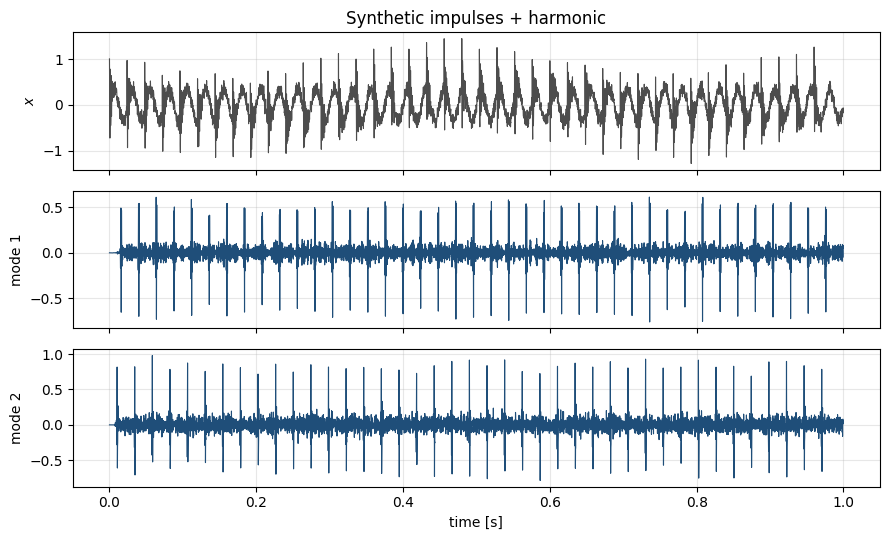

In [2]:
fs_s = 5000.0
n_s = 5000
period = 120
t_s = np.arange(n_s) / fs_s
fn, decay = 900.0, 350.0
tk = np.arange(period) / fs_s
kernel = np.exp(-decay * tk) * np.cos(2 * np.pi * fn * tk)
x_s = np.zeros(n_s)
for start in range(0, n_s - period, period):
    x_s[start : start + period] += kernel
x_s += 0.08 * np.random.default_rng(0).standard_normal(n_s)

# add a low-frequency harmonic interferer
x_s = x_s + 0.35 * np.sin(2 * np.pi * 40 * t_s)

fmd_s = FMD(fs=fs_s, mode_num=2, filter_size=30, cut_num=5, max_iter_num=12)
modes_s = fmd_s.fit_transform(x_s)
print("peak freqs [Hz]:", fmd_s.peak_freqs)

fig, axes = plt.subplots(3, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(t_s, x_s, color="0.3", lw=0.8)
axes[0].set_ylabel("$x$")
axes[0].set_title("Synthetic impulses + harmonic")
for i, ax in enumerate(axes[1:]):
    ax.plot(t_s, modes_s[i], color="#1f4e79", lw=0.8)
    ax.set_ylabel(f"mode {i+1}")
axes[-1].set_xlabel("time [s]")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. MATLAB File Exchange demo (`x.mat` → `test_fmd`)

Parameters match `demo.m`:

```matlab
fs = 2e4; filtersize = 30; cutnum = 7; modenum = 2; maxiternum = 20;
y_final = FMD(fs, x, filtersize, cutnum, modenum, maxiternum);
```

The signal is shipped as `pysdkit/data/real_world/fmd_demo.npy` and loaded by
`test_fmd()` so it installs with the PyPI package.

N=20001, fs=20000 Hz, duration=1.000 s


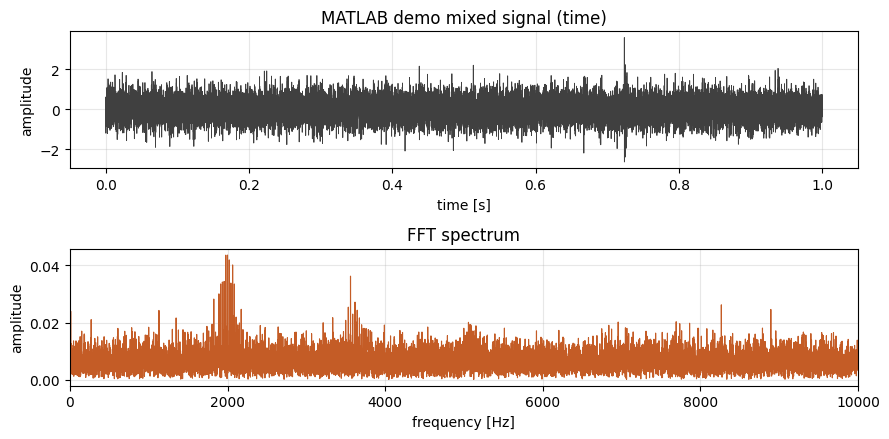

In [3]:
t, x, fs = test_fmd()
print(f"N={x.size}, fs={fs:.0f} Hz, duration={t[-1]:.3f} s")

fig, axes = plt.subplots(2, 1, figsize=(9, 4.5))
axes[0].plot(t, x, color="0.25", lw=0.6)
axes[0].set_ylabel("amplitude")
axes[0].set_title("MATLAB demo mixed signal (time)")
axes[0].set_xlabel("time [s]")

X = np.fft.rfft(x)
freq = np.fft.rfftfreq(x.size, d=1 / fs)
axes[1].plot(freq, np.abs(X) * 2 / x.size, color="#c45c26", lw=0.8)
axes[1].set_xlim(0, fs / 2)
axes[1].set_xlabel("frequency [Hz]")
axes[1].set_ylabel("amplitude")
axes[1].set_title("FFT spectrum")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modes: (2, 20001)
filter peak freqs [Hz]: [6666.66666667 2666.66666667]


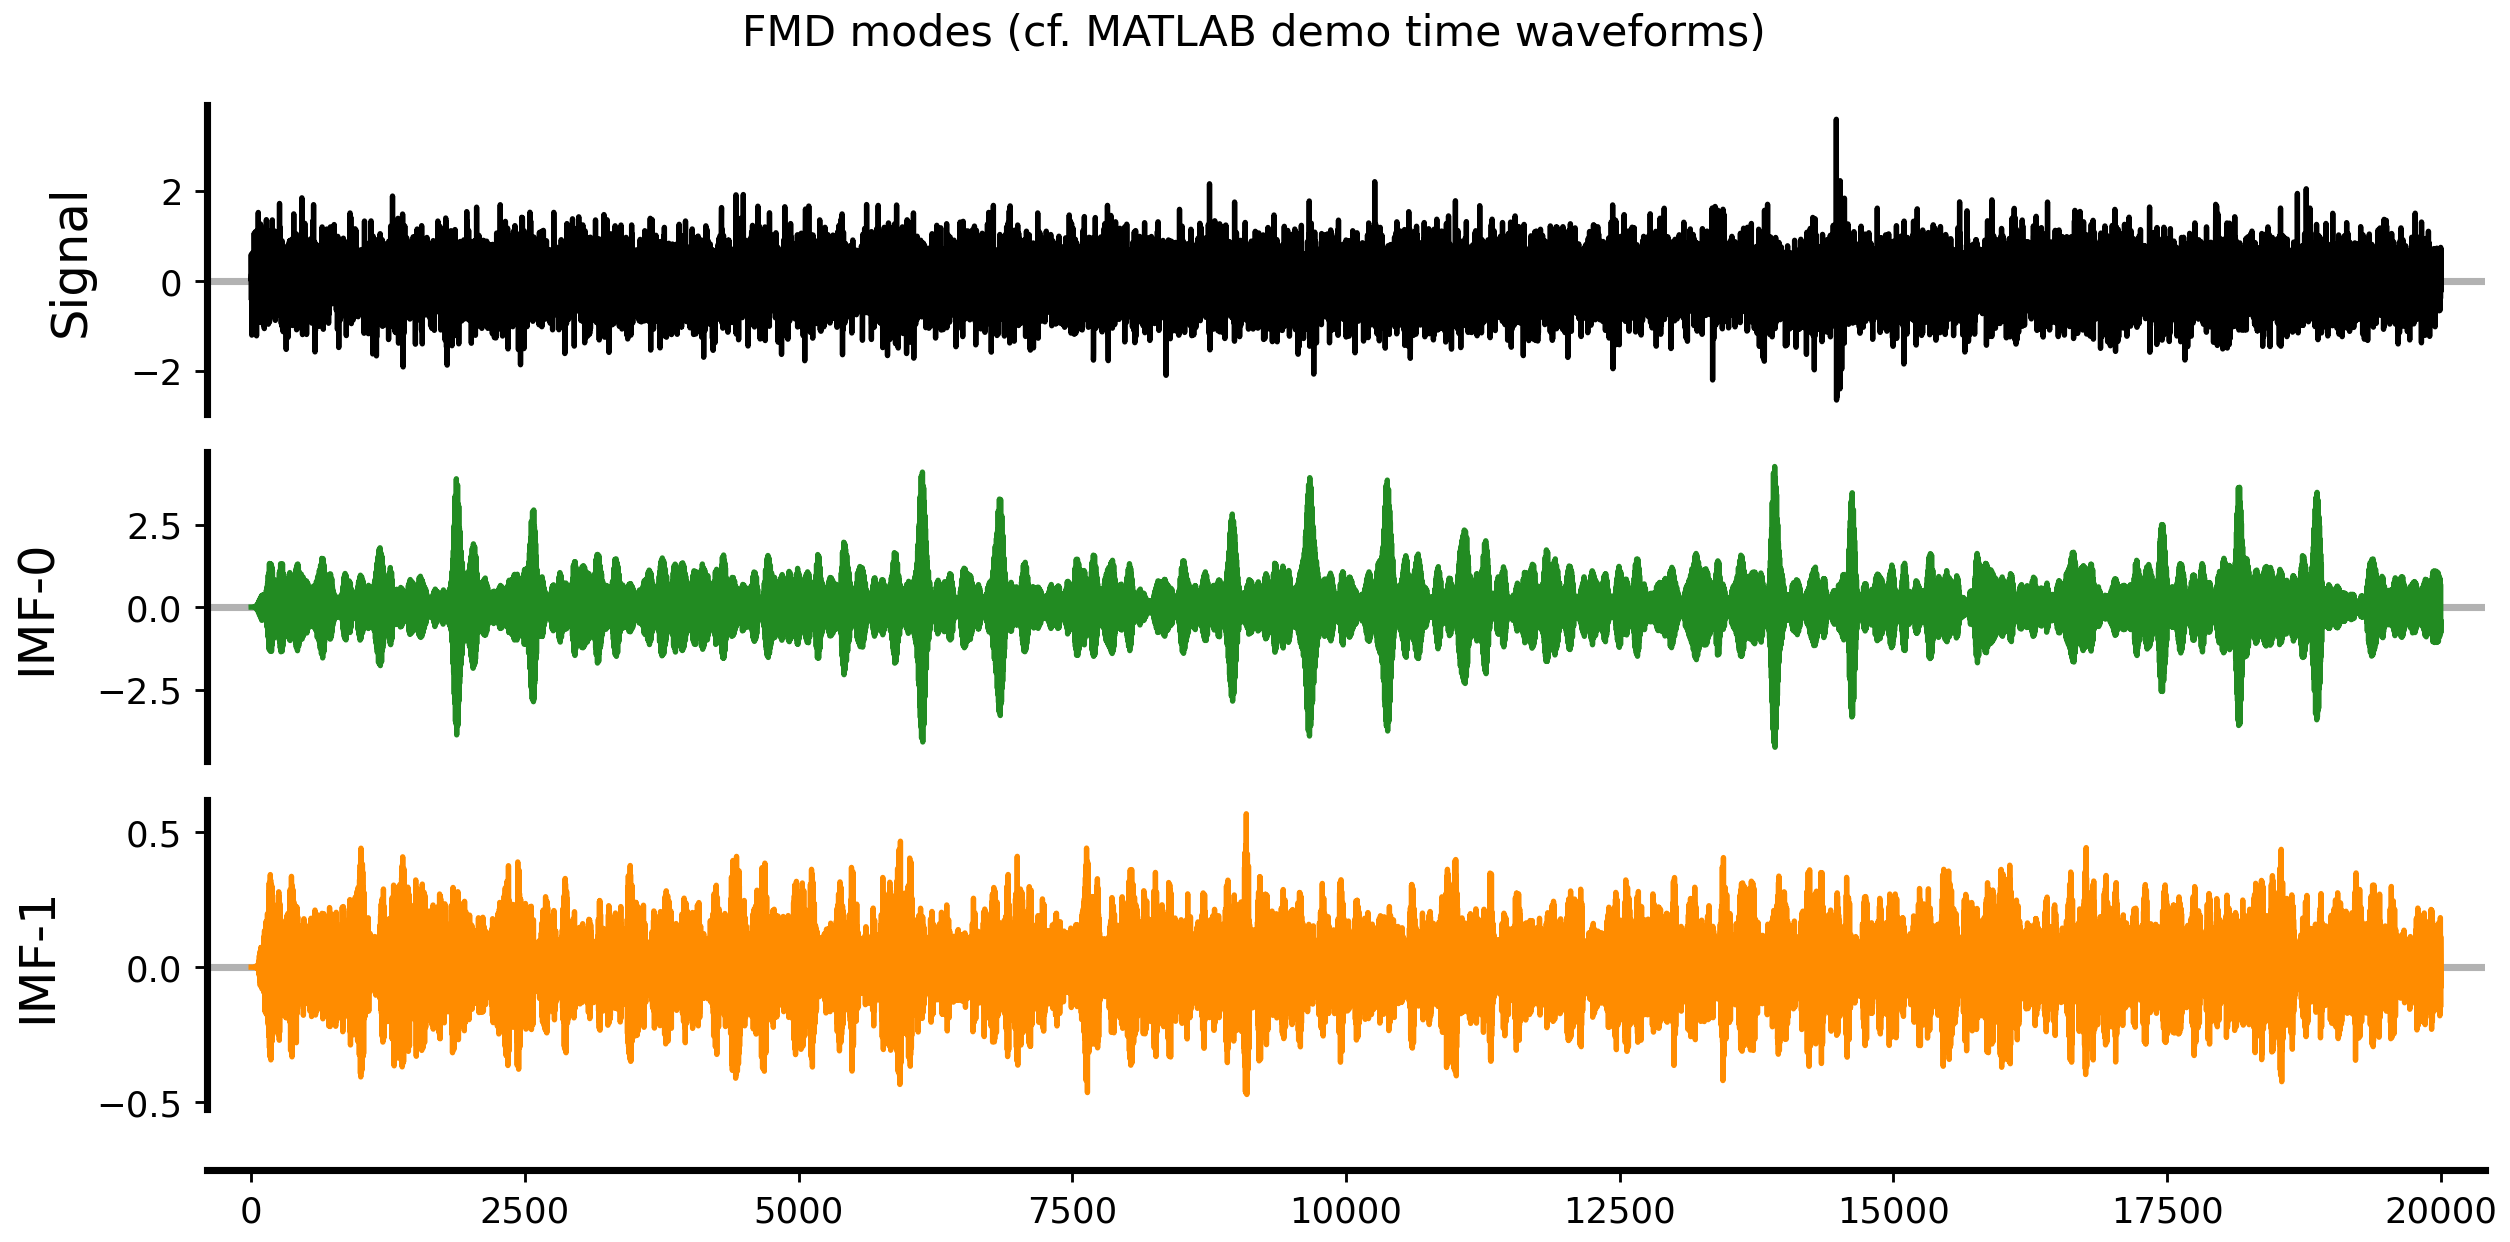

In [4]:
fmd = FMD(fs=fs, filter_size=30, cut_num=7, mode_num=2, max_iter_num=20)
modes = fmd.fit_transform(x)
print("modes:", modes.shape)
print("filter peak freqs [Hz]:", fmd.peak_freqs)

fig = plot_IMFs(x, modes)
plt.suptitle("FMD modes (cf. MATLAB demo time waveforms)")
plt.tight_layout()
plt.show()

### Spectra and Hilbert envelope spectra

Mirrors the FFT / envelope plots in `demo.m` — envelope spectra reveal
the fault characteristic frequencies after FMD isolates the impulsive mode.

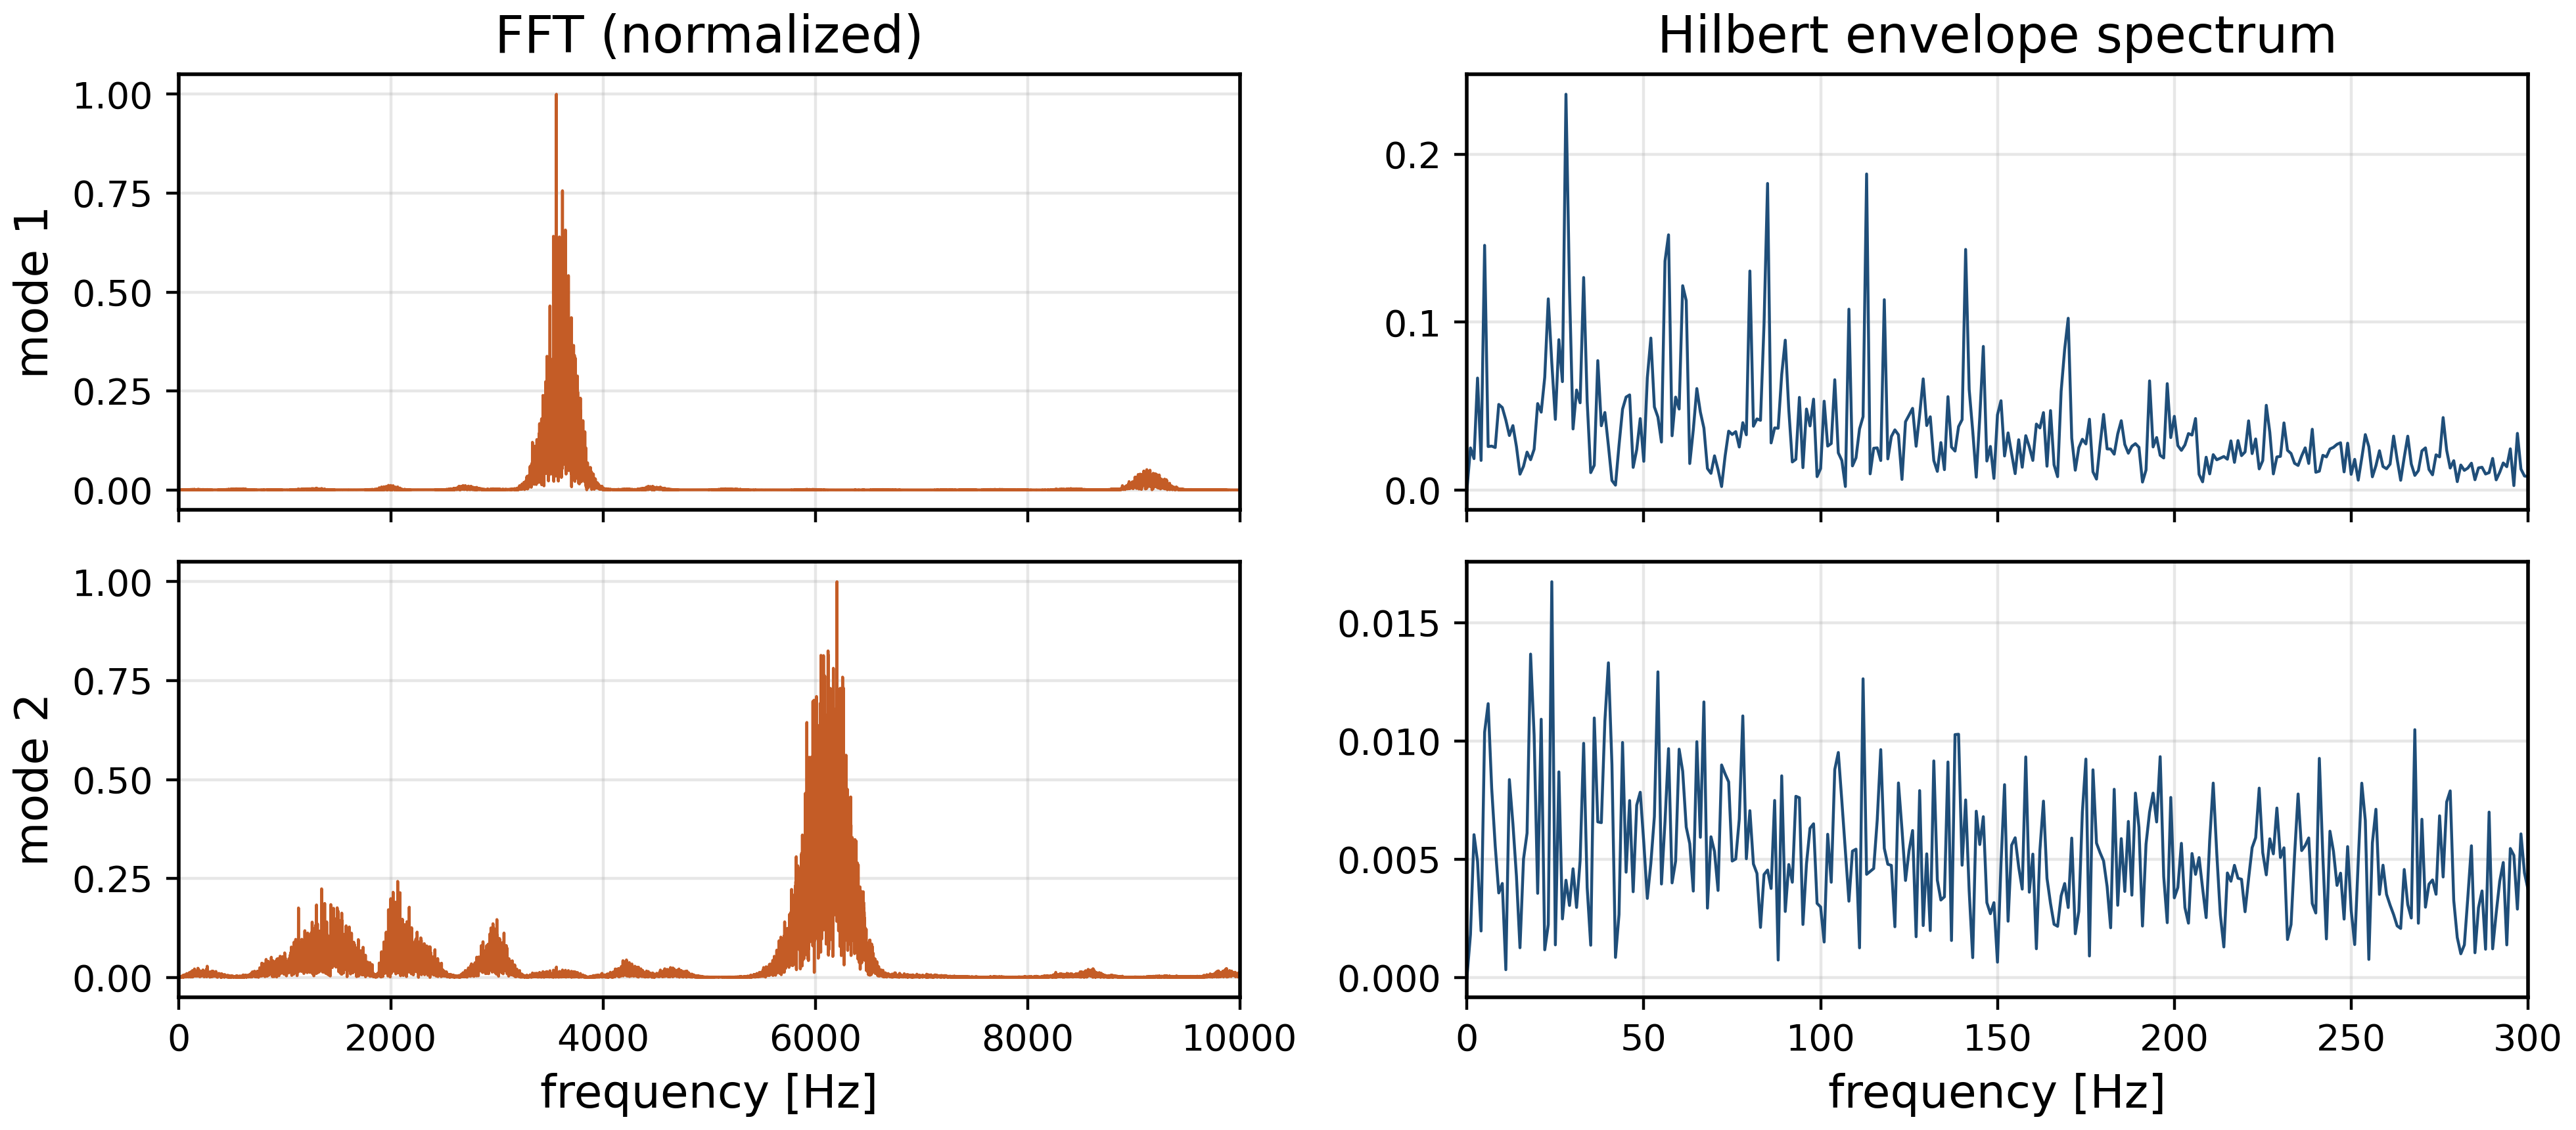

In [5]:
fig, axes = plt.subplots(modes.shape[0], 2, figsize=(10, 4.5), sharex="col")
if modes.shape[0] == 1:
    axes = np.asarray([axes])

for k, mode in enumerate(modes):
    ff = np.fft.rfftfreq(mode.size, d=1 / fs)
    amp = np.abs(np.fft.rfft(mode)) * 2 / mode.size
    axes[k, 0].plot(ff, amp / (amp.max() + 1e-12), color="#c45c26", lw=0.8)
    axes[k, 0].set_ylabel(f"mode {k+1}")
    axes[k, 0].set_xlim(0, fs / 2)
    axes[k, 0].grid(True, alpha=0.3)

    env = np.abs(hilbert(mode)) - np.mean(np.abs(hilbert(mode)))
    e_amp = np.abs(np.fft.rfft(env)) * 2 / env.size
    axes[k, 1].plot(ff, e_amp, color="#1f4e79", lw=0.8)
    axes[k, 1].set_xlim(0, 300)
    axes[k, 1].grid(True, alpha=0.3)

axes[0, 0].set_title("FFT (normalized)")
axes[0, 1].set_title("Hilbert envelope spectrum")
axes[-1, 0].set_xlabel("frequency [Hz]")
axes[-1, 1].set_xlabel("frequency [Hz]")
plt.tight_layout()
plt.show()

## 5. API summary

```python
from pysdkit import FMD
from pysdkit.data import test_fmd

t, x, fs = test_fmd()                      # packaged MATLAB demo
fmd = FMD(fs=fs, filter_size=30, cut_num=7, mode_num=2, max_iter_num=20)
modes = fmd.fit_transform(x)               # (mode_num, N)
# fmd.filters, fmd.peak_freqs, fmd.imfs
```

## 6. Takeaways

- FMD is a **non-recursive** FIR-bank method aimed at **rotating-machinery faults**.
- The objective is **CK** (impulsiveness × periodicity), not bandwidth or extrema.
- Hanning sub-band initialization + IMCKD updates + correlation-based pruning
  yield a small set of feature modes.
- Choose `cut_num` ≥ `mode_num`; larger `filter_size` gives sharper FIRs at
  higher cost.